In [ ]:
!pip install scikit-learn==1.3.2 biopython gensim umap-learn

In [9]:
import pandas as pd
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
from gensim.models import Word2Vec

from joblib import load
import lightgbm as lgb
from joblib import dump
import itertools
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

import umap
import seaborn as sns

In [2]:
rice_df = pd.read_excel('rice_w2vec_3mer_64_dataset.xlsx')
rice_df = rice_df.drop(['tissue','chr','start','end','strand','start_anno', 'circID',	'gene', 'isoform', 'width', 'detection_score', 'stress_detection_score', 'end_anno', 'antisense', 'algorithm', 'exonSeq', 'predAA', 'miRNA','superCircRNARegion'], axis=1)

In [3]:
df_cold = rice_df.query('stress == "-" or stress == "cold"').replace('-', 0).replace('cold', 1)
df_cold

/tmp/ipython-input-725488738.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cold = rice_df.query('stress == "-" or stress == "cold"').replace('-', 0).replace('cold', 1)


,circName,stress,seq,wc_3mer_1,wc_3mer_2,wc_3mer_3,wc_3mer_4,wc_3mer_5,wc_3mer_6,wc_3mer_7,...,wc_3mer_55,wc_3mer_56,wc_3mer_57,wc_3mer_58,wc_3mer_59,wc_3mer_60,wc_3mer_61,wc_3mer_62,wc_3mer_63,wc_3mer_64
0,osa-circ1-OS01T0723400,0,AGGGGAATGAGAGGCTTTTCTACAAGCTCCTCATTGACAATGTTGA...,-8.660600,-17.171770,-20.124799,10.607480,-0.194991,1.568289,3.896590,...,-21.976927,-12.450649,-8.376489,-9.521074,28.565338,7.251650,-18.073032,-6.670159,-3.779034,1.302005
1,osa-circ2-OS03T0223400,0,CTCATCCCTGCTTCCTCTTCTACACCTCATTTTCCGCTTGCATCTT...,-4.623322,-42.058749,-73.491472,-51.222795,83.974883,-47.219114,-20.222901,...,24.437080,-68.490463,20.158427,14.177653,81.437811,-4.524170,21.867150,-10.532807,-39.172970,63.339612
2,osa-circ3-OS11T0210300,0,ACCGGTTTTGATTTGATCTGTGTGATTTGAGTGAGTGAGTGAGATT...,-23.932238,-17.885510,-54.202845,15.682650,-30.424396,13.430986,-15.981544,...,-34.355928,13.556080,-50.537661,-30.186757,64.202528,54.450606,-24.835176,2.558572,-9.287752,-25.051924
3,osa-circ4-OS02T0200900,0,TCCGTTCCCCCCTCCACTTTCCCCATCTCCGACACCTCTCTCCTCT...,-42.541243,-44.121847,-54.312436,-37.621338,53.242821,6.651359,-9.533580,...,74.941825,-37.716935,-19.644171,36.562092,62.745595,14.111886,46.643984,-12.691884,40.033801,-0.980058
4,osa-circ5-OS05T0494800,0,CGAGGGTCAGGACGAATATGAGAAGGATGGCTTCATAGTAGATGAT...,-9.970732,20.265143,-4.832509,39.979788,-9.345131,-2.708796,13.024784,...,-49.435175,33.124836,-4.937962,-21.755058,-0.672400,39.981767,-57.044162,-18.266155,-12.560292,-41.720146
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63043,osa-circ63044--,0,CATCCATTGCCTCGATTTTCTATTCCAAATTCCCCCACGCGAAGAA...,-36.129064,-13.508832,0.005943,-11.045796,34.350577,-12.069487,11.820539,...,71.354353,-16.542512,2.488324,37.899663,7.770607,-1.294477,27.140534,-35.586348,42.826113,1.914022
63044,osa-circ63045--,0,TGGCGCCAGAGCCCGCCGCCGCCGCCGAGGCGGAGGCCAAGGAGGC...,-81.022365,16.294278,78.293930,78.380937,31.556227,34.236833,50.813806,...,117.117149,79.811355,-51.199810,132.507834,32.852214,35.095596,34.001745,-10.350830,162.961049,-95.637550
63045,osa-circ63046--,0,TGGCGGAGACGGAGTGCTCGCCAGCGGCGACGGCGTAGCGGAGGAG...,-46.754698,10.391865,38.252494,51.685485,21.559602,32.210430,50.047768,...,61.597804,66.569489,-50.207208,85.853744,44.182827,53.164509,15.902078,18.139559,116.782359,-77.869255
63046,osa-circ63047--,0,AACTGATTGGTGGGGCCCATCGTGGCCAGTTATCCTTAGCTATCCG...,-19.736442,-30.662747,-21.114486,7.117133,24.859926,13.406382,-1.219863,...,22.584763,-23.609748,-10.552717,18.842086,36.384463,-20.618450,16.068993,1.198586,2.631869,0.869086


In [4]:
# Define X and y (target) variables
X = df_cold.drop(['stress', 'circName', 'seq'], axis=1)
y = df_cold['stress']

In [5]:
y.value_counts()

,count
stress,
0,50187
1,5724


In [6]:
X.head()

,wc_3mer_1,wc_3mer_2,wc_3mer_3,wc_3mer_4,wc_3mer_5,wc_3mer_6,wc_3mer_7,wc_3mer_8,wc_3mer_9,wc_3mer_10,...,wc_3mer_55,wc_3mer_56,wc_3mer_57,wc_3mer_58,wc_3mer_59,wc_3mer_60,wc_3mer_61,wc_3mer_62,wc_3mer_63,wc_3mer_64
0,-8.660600,-17.171770,-20.124799,10.607480,-0.194991,1.568289,3.896590,7.622823,-2.833792,13.902024,...,-21.976927,-12.450649,-8.376489,-9.521074,28.565338,7.251650,-18.073032,-6.670159,-3.779034,1.302005
1,-4.623322,-42.058749,-73.491472,-51.222795,83.974883,-47.219114,-20.222901,29.187759,-17.144830,37.219912,...,24.437080,-68.490463,20.158427,14.177653,81.437811,-4.524170,21.867150,-10.532807,-39.172970,63.339612
2,-23.932238,-17.885510,-54.202845,15.682650,-30.424396,13.430986,-15.981544,27.324571,24.285038,-17.966888,...,-34.355928,13.556080,-50.537661,-30.186757,64.202528,54.450606,-24.835176,2.558572,-9.287752,-25.051924
3,-42.541243,-44.121847,-54.312436,-37.621338,53.242821,6.651359,-9.533580,22.141600,-23.691575,9.283776,...,74.941825,-37.716935,-19.644171,36.562092,62.745595,14.111886,46.643984,-12.691884,40.033801,-0.980058
4,-9.970732,20.265143,-4.832509,39.979788,-9.345131,-2.708796,13.024784,8.689754,20.483825,-24.362307,...,-49.435175,33.124836,-4.937962,-21.755058,-0.672400,39.981767,-57.044162,-18.266155,-12.560292,-41.720146


In [7]:
ros = RandomUnderSampler(sampling_strategy=0.7)

X_res, y_res = ros.fit_resample(X, y)
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.20, random_state=320)

In [8]:
cold_model = load('rf_model_cold_3mer.joblib')

In [10]:
w2v_model_rice = Word2Vec.load("word2vec_model_rice_3mer.bin")

In [11]:
def get_kmers_for_dimension(model, dim_idx, top_n=10):
    words = list(model.wv.index_to_key)
    vectors = model.wv.vectors
    sorted_indices = np.argsort(vectors[:, dim_idx])[::-1]

    return [words[i] for i in sorted_indices[:top_n]]



### SHAP

In [12]:
import shap

# Sample
X_test_sample = X_test.sample(n=min(1000, len(X_test)), random_state=320)

explainer = shap.TreeExplainer(cold_model)

shap_values = explainer.shap_values(X_test_sample, check_additivity=False)

In [13]:
if isinstance(shap_values, list):
    shap_to_use = shap_values[1]
elif len(shap_values.shape) == 3:
    shap_to_use = shap_values[:, :, 1]
else:
    shap_to_use = shap_values

mean_shap = np.abs(shap_to_use).mean(axis=0)


df_impacto = pd.DataFrame({
    'Feature': X_test_sample.columns[:len(mean_shap)],
    'SHAP_Importance': mean_shap
})

top_features = df_impacto.nlargest(5, 'SHAP_Importance')
top_features

,Feature,SHAP_Importance
20,wc_3mer_21,0.029308
43,wc_3mer_44,0.023063
48,wc_3mer_49,0.020226
11,wc_3mer_12,0.018591
39,wc_3mer_40,0.014768


## Density Analysis

<>:55: SyntaxWarning: invalid escape sequence '\D'
<>:55: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipython-input-667300892.py:55: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('Delta Density ($\Delta$)', fontsize=14)


Success: kmer_density_signature_cold.tiff


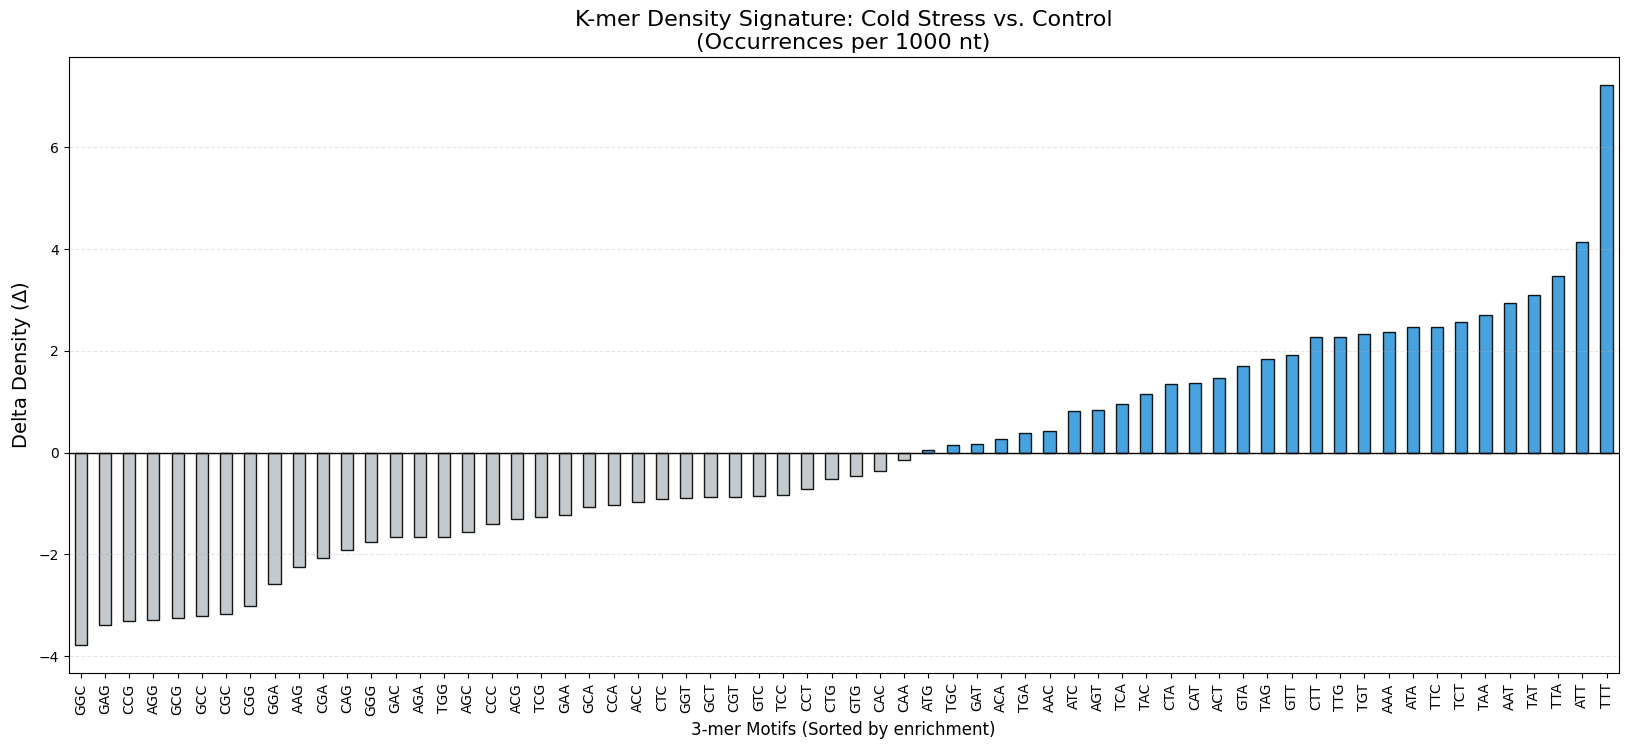


TOP 10 COLD-ENRICHED 3-mers
condition       Cold    Control     Delta
TTT        37.404041  30.192228  7.211812
ATT        26.314374  22.173617  4.140757
TTA        19.271782  15.798163  3.473619
TAT        21.388695  18.298817  3.089878
AAT        22.010048  19.063983  2.946065
TAA        16.035524  13.335544  2.699979
TCT        22.877121  20.301146  2.575974
TTC        23.277410  20.800153  2.477257
ATA        17.480870  15.004499  2.476371
AAA        24.057984  21.692274  2.365709

TOP 10 COLD-DEPLETED 3-mers (CONTROL-ENRICHED)
condition       Cold    Control     Delta
GGC         9.795327  13.582414 -3.787087
GAG        13.293586  16.677484 -3.383898
CCG         6.353397   9.650932 -3.297535
AGG        11.753880  15.049567 -3.295687
GCG         6.726616   9.964590 -3.237974
GCC         9.827986  13.044965 -3.216980
CGC         7.039711  10.218160 -3.178449
CGG         6.196712   9.205510 -3.008799
GGA        14.177371  16.751171 -2.573800
AAG        16.975896  19.214744 -2.238848

In [17]:
from itertools import product
from collections import Counter

# Generate all possible 3-mer combinations (64 total)
all_3mers = [''.join(p) for p in product('ACGT', repeat=3)]

def calculate_kmer_density(seq):
    """
    Calculates the density of each 3-mer normalized per 1000 nucleotides.
    """
    seq = str(seq).upper()
    seq_len = len(seq)

    if seq_len < 3:
        return pd.Series([0.0]*64, index=all_3mers)

    # Extract all overlapping 3-mers
    kmers_in_seq = [seq[i:i+3] for i in range(seq_len - 2)]
    counts = Counter(kmers_in_seq)

    # Formula: (Count / Sequence Length) * 1000
    densities = [(counts[kmer] / seq_len) * 1000 for kmer in all_3mers]
    return pd.Series(densities, index=all_3mers)

# Filter dataset for Control (-) and Cold stress conditions
df_analysis = rice_df.query('stress == "-" or stress == "cold"').copy()
df_analysis['condition'] = df_analysis['stress'].replace({'-': 'Control', 'cold': 'Cold'})

# Apply density calculation to the sequences
kmer_densities = df_analysis['seq'].apply(calculate_kmer_density)

# Combine labels with density data
df_final = pd.concat([df_analysis[['condition']], kmer_densities], axis=1)

# Calculate Mean Density per group
summary = df_final.groupby('condition')[all_3mers].mean()
diff_summary = summary.T

# Compute Delta (Difference) and Relative Variation
diff_summary['Delta'] = diff_summary['Cold'] - diff_summary['Control']
diff_summary['Rel_Change_Pct'] = (diff_summary['Delta'] / diff_summary['Control']) * 100

# --- Visualization: Delta Density Bar Chart ---
plt.figure(figsize=(20, 8))
ordered_diff = diff_summary.sort_values(by='Delta')

# Adjusted Color mapping:
# SteelBlue (#3498db) for positive delta (Cold-enriched)
# Silver/Grey (#bdc3c7) for negative delta (Cold-depleted)
colors = ['#3498db' if x > 0 else '#bdc3c7' for x in ordered_diff['Delta']]

ordered_diff['Delta'].plot(kind='bar', color=colors, edgecolor='black', alpha=0.9)

plt.title('K-mer Density Signature: Cold Stress vs. Control\n(Occurrences per 1000 nt)', fontsize=16)
plt.ylabel('Delta Density ($\Delta$)', fontsize=14)
plt.xlabel('3-mer Motifs (Sorted by enrichment)', fontsize=12)
plt.axhline(0, color='black', linewidth=1)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.savefig('kmer_density_signature_cold.tiff',
            dpi=300,
            format='tiff',
            bbox_inches='tight',
            pil_kwargs={'compression': 'tiff_lzw'})

print("Success: kmer_density_signature_cold.tiff")
plt.show()

# --- Print Top 10 Enriched and Depleted Motifs ---
print("\n" + "="*50)
print("TOP 10 COLD-ENRICHED 3-mers")
print("="*50)
print(ordered_diff[['Cold', 'Control', 'Delta']].tail(10).iloc[::-1])

print("\n" + "="*50)
print("TOP 10 COLD-DEPLETED 3-mers (CONTROL-ENRICHED)")
print("="*50)
print(ordered_diff[['Cold', 'Control', 'Delta']].head(10))

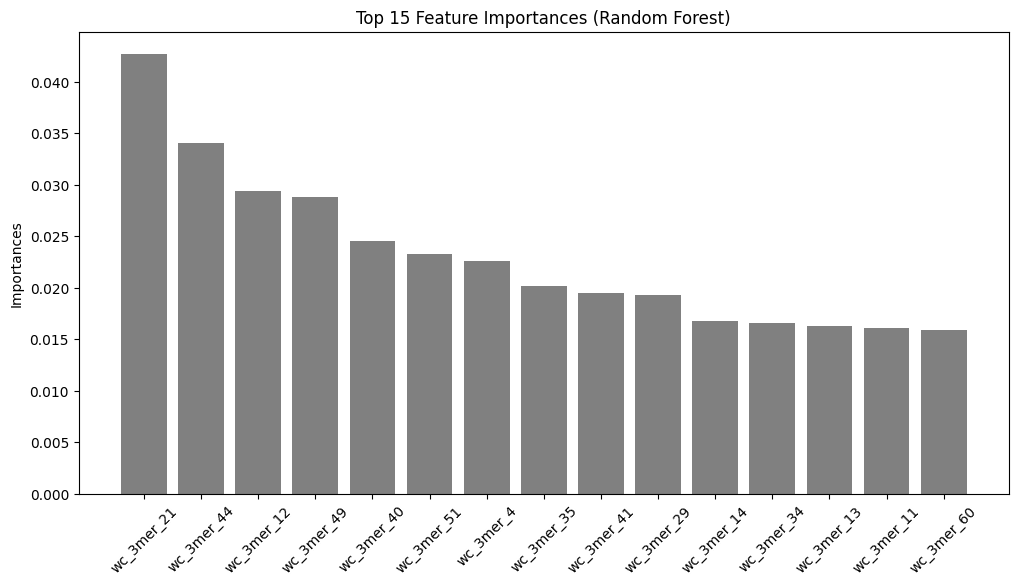

       Feature  Importance
20  wc_3mer_21    0.042720
43  wc_3mer_44    0.034020
11  wc_3mer_12    0.029419
48  wc_3mer_49    0.028758
39  wc_3mer_40    0.024515
50  wc_3mer_51    0.023275
3    wc_3mer_4    0.022566
34  wc_3mer_35    0.020182
40  wc_3mer_41    0.019505
28  wc_3mer_29    0.019253
13  wc_3mer_14    0.016752
33  wc_3mer_34    0.016534
12  wc_3mer_13    0.016260
10  wc_3mer_11    0.016070
59  wc_3mer_60    0.015859


In [18]:
importances = cold_model.feature_importances_
feature_names = [f'wc_3mer_{i+1}' for i in range(len(importances))]

df_importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(df_importances['Feature'].head(15), df_importances['Importance'].head(15), color='grey')
plt.xticks(rotation=45)
plt.title('Top 15 Feature Importances (Random Forest)')
plt.ylabel('Importances')
plt.show()

print(df_importances.head(15))

In [19]:
# 1. Configuration
target_dimensions = [21, 44, 12, 49]
# Matches your Word2Vec prefix (e.g., 'wc_3mer_21')
prefix = 'wc_3mer'

# 2. Access Word2Vec Data
vectors = w2v_model_rice.wv.vectors
kmers = w2v_model_rice.wv.index_to_key

# Dictionary to store results for each dimension
dimension_results = {}

print(f"--- QUANTITATIVE ANALYSIS OF TOP SHAP DIMENSIONS ---")

for dim in target_dimensions:
    # Index Adjustment: Column name '49' corresponds to Python index 48
    python_idx = dim - 1

    # Extract weights and calculate relative contribution percentage
    vector_weights = vectors[:, python_idx]
    squared_importance = vector_weights**2
    contribution_pct = (squared_importance / squared_importance.sum()) * 100

    # Create DataFrame for the current dimension
    df_dim = pd.DataFrame({
        'K-mer': kmers,
        'Weight': vector_weights,
        'Contribution_Pct': contribution_pct
    })

    # Sort by absolute strength (Contribution %)
    top_10 = df_dim.sort_values(by='Contribution_Pct', ascending=False).head(10)
    dimension_results[dim] = top_10

    # Formatted Output
    print(f"\n>> {prefix}_{dim} (Actual Index: {python_idx})")
    print(top_10.to_string(index=False))
    print("-" * 50)

--- QUANTITATIVE ANALYSIS OF TOP SHAP DIMENSIONS ---

>> wc_3mer_21 (Actual Index: 20)
K-mer    Weight  Contribution_Pct
  ACG -1.540356          7.235658
  TCA  1.435201          6.281472
  TAC  1.409363          6.057336
  ACC -1.372356          5.743403
  AGC -1.342601          5.497050
  CTG -1.100935          3.696235
  AGG -1.090251          3.624842
  TTC -1.067432          3.474692
  TTG -1.050028          3.362312
  CAG -1.005692          3.084365
--------------------------------------------------

>> wc_3mer_44 (Actual Index: 43)
K-mer    Weight  Contribution_Pct
  AGG  2.210177          9.810843
  GAA -2.024131          8.228669
  GCA -1.910323          7.329357
  CGG  1.582776          5.031428
  CCA -1.573180          4.970604
  GGA -1.427225          4.091073
  GAC -1.390340          3.882349
  GGC -1.351377          3.667796
  ACC  1.336849          3.589360
  GGT -1.331453          3.560442
--------------------------------------------------

>> wc_3mer_12 (Actual Index:

In [20]:
df_analysis_cold = rice_df.query('stress == "cold"')

In [21]:
df_analysis_control = rice_df.query('stress == "-"')

In [22]:
# 1. Apply the density calculation to the control group sequences
control_densities = df_analysis_control['seq'].apply(calculate_kmer_density)

# 2. Calculate the MEAN density for the entire group
# This represents the average occurrence of each k-mer per 1000nt across all transcripts
mean_density_control = control_densities.mean()

# 3. Convert to DataFrame and sort by density
df_final_ctrl = mean_density_control.to_frame(name='Mean_Density_Per_1000nt')
df_final_ctrl.index.name = 'K-mer'
df_final_ctrl = df_final_ctrl.sort_values(by='Mean_Density_Per_1000nt', ascending=False)

# 4. Print results using standardized English headers
print("="*50)
print(f"{'TOP 10 HIGHEST DENSITY (CONTROL GROUP)':^50}")
print("="*50)
print(df_final_ctrl.head(10))

print("\n" + "="*50)
print(f"{'TOP 10 LOWEST DENSITY (CONTROL GROUP)':^50}")
print("="*50)
print(df_final_ctrl.tail(10))

      TOP 10 HIGHEST DENSITY (CONTROL GROUP)      
       Mean_Density_Per_1000nt
K-mer                         
TTT                  30.192228
TTG                  24.115255
ATT                  22.173617
AAA                  21.692274
ATG                  21.227240
TGA                  20.951043
TTC                  20.800153
TGT                  20.366205
TCT                  20.301146
CTT                  20.139499

      TOP 10 LOWEST DENSITY (CONTROL GROUP)       
       Mean_Density_Per_1000nt
K-mer                         
CGC                  10.218160
TAG                  10.115920
CCC                  10.009900
GCG                   9.964590
CCG                   9.650932
TCG                   9.631518
CGG                   9.205510
CGA                   8.882056
CGT                   7.572670
ACG                   6.669348


In [23]:
# 1. Apply the density calculation to the cold stress group sequences
cold_densities = df_analysis_cold['seq'].apply(calculate_kmer_density)

# 2. Calculate the MEAN density for the entire cold stress group
# This provides the average genomic signature under stress conditions
mean_density_cold = cold_densities.mean()

# 3. Convert to DataFrame and sort by mean density
df_final_cold = mean_density_cold.to_frame(name='Mean_Density_Per_1000nt')
df_final_cold.index.name = 'K-mer'
df_final_cold = df_final_cold.sort_values(by='Mean_Density_Per_1000nt', ascending=False)

# 4. Print results using standardized English headers
print("="*50)
print(f"{'TOP 10 HIGHEST DENSITY (COLD STRESS GROUP)':^50}")
print("="*50)
print(df_final_cold.head(10))

print("\n" + "="*50)
print(f"{'TOP 10 LOWEST DENSITY (COLD STRESS GROUP)':^50}")
print("="*50)
print(df_final_cold.tail(10))

    TOP 10 HIGHEST DENSITY (COLD STRESS GROUP)    
       Mean_Density_Per_1000nt
K-mer                         
TTT                  37.404041
TTG                  26.393431
ATT                  26.314374
AAA                  24.057984
TTC                  23.277410
TCT                  22.877121
TGT                  22.690443
CTT                  22.412266
AAT                  22.010048
TAT                  21.388695

    TOP 10 LOWEST DENSITY (COLD STRESS GROUP)     
       Mean_Density_Per_1000nt
K-mer                         
GGG                   8.741506
CCC                   8.603945
TCG                   8.362484
CGC                   7.039711
CGA                   6.817940
GCG                   6.726616
CGT                   6.704659
CCG                   6.353397
CGG                   6.196712
ACG                   5.365289


In [24]:
def get_group_mean_densities(group_df, group_name):
    print(f"Processing {group_name} ({len(group_df)} sequences)...")
    # Apply calculation to all sequences in the group
    densities_df = group_df['seq'].apply(calculate_kmer_density)
    return densities_df.mean()

# 2. Generate baseline variables for both conditions
mean_control = get_group_mean_densities(df_analysis_control, "Control")
mean_cold = get_group_mean_densities(df_analysis_cold, "Cold Stress")

# 3. Construct the Comparative DataFrame
df_comp = pd.DataFrame({
    'Control_Avg': mean_control,
    'Cold_Avg': mean_cold
})

# 4. Statistical Calculations
# Delta (Diff): Absolute difference
df_comp['Delta'] = df_comp['Cold_Avg'] - df_comp['Control_Avg']

# Fold-Change (Ratio): Proportional increase
# Offset of 0.01 prevents division by zero and stabilizes low-density ratios
df_comp['Fold_Change'] = (df_comp['Cold_Avg'] + 0.01) / (df_comp['Control_Avg'] + 0.01)

# Log2 Fold-Change: Standard for symmetry in differential expression analysis
df_comp['Log2FC'] = np.log2(df_comp['Fold_Change'])

# 5. Filter and Sort: Cold-Enriched Markers (Up-regulated)
# Criteria: Fold-Change > 1.5 and minimum density in Cold Stress > 2.0
up_regulated_markers = df_comp[
    (df_comp['Fold_Change'] > 1.5) & (df_comp['Cold_Avg'] > 2.0)
].sort_values(by='Log2FC', ascending=False)

# 6. Filter and Sort: Cold-Depleted Markers (Down-regulated)
# Criteria: Fold-Change < 0.66 and minimum density in Control > 2.0
down_regulated_markers = df_comp[
    (df_comp['Fold_Change'] < 0.66) & (df_comp['Control_Avg'] > 2.0)
].sort_values(by='Log2FC', ascending=True)

# --- RESULTS REPORTING ---
print("\n" + "="*70)
print(f"{'TOP COLD-ENRICHED MARKERS (PROPORTIONAL CHANGE)':^70}")
print("="*70)
if not up_regulated_markers.empty:
    print(up_regulated_markers.head(15))
else:
    print("No k-mers passed the enrichment threshold (Fold-Change > 1.5)")

print("\n" + "="*70)
print(f"{'TOP COLD-DEPLETED MARKERS (PROPORTIONAL CHANGE)':^70}")
print("="*70)
if not down_regulated_markers.empty:
    print(down_regulated_markers.head(15))
else:
    print("No k-mers passed the depletion threshold (Fold-Change < 0.66)")

Processing Control (50187 sequences)...
Processing Cold Stress (5724 sequences)...

           TOP COLD-ENRICHED MARKERS (PROPORTIONAL CHANGE)            
No k-mers passed the enrichment threshold (Fold-Change > 1.5)

           TOP COLD-DEPLETED MARKERS (PROPORTIONAL CHANGE)            
     Control_Avg  Cold_Avg     Delta  Fold_Change    Log2FC
CCG     9.650932  6.353397 -3.297535     0.658673 -0.602365


In [25]:
# Sensitive filter: Fold_Change > 1.2 (20% increase)
# This captures subtle enrichment that might be biologically relevant
subtle_enriched_markers = df_comp[
    (df_comp['Fold_Change'] > 1.2) & (df_comp['Cold_Avg'] > 2.0)
].sort_values(by='Fold_Change', ascending=False)

print("\n" + "="*70)
print(f"{'MARKERS WITH SUBTLE ENRICHMENT (> 20% INCREASE)':^70}")
print("="*70)
if not subtle_enriched_markers.empty:
    print(subtle_enriched_markers.head(10))
else:
    print("No k-mers met the 20% enrichment threshold.")


           MARKERS WITH SUBTLE ENRICHMENT (> 20% INCREASE)            
     Control_Avg   Cold_Avg     Delta  Fold_Change    Log2FC
TTT    30.192228  37.404041  7.211812     1.238784  0.308925
TTA    15.798163  19.271782  3.473619     1.219736  0.286569
TAA    13.335544  16.035524  2.699979     1.202313  0.265813


In [26]:
# --- SYMMETRIC ANALYSIS (20% Threshold) ---

# 1. Cold-Enriched Markers (Up-regulated)
# Threshold: > 20% increase (Fold_Change > 1.2)
enriched_subtle = df_comp[
    (df_comp['Fold_Change'] > 1.2) & (df_comp['Cold_Avg'] > 2.0)
].sort_values(by='Log2FC', ascending=False)

# 2. Cold-Depleted Markers (Down-regulated)
# Threshold: > 20% decrease (Fold_Change < 0.833)
# Note: 1/1.2 = 0.833 ensures mathematical symmetry
depleted_subtle = df_comp[
    (df_comp['Fold_Change'] < 0.833) & (df_comp['Control_Avg'] > 2.0)
].sort_values(by='Log2FC', ascending=True)

# --- RESULTS REPORTING ---
print("\n" + "="*75)
print(f"{'SYMMETRIC ANALYSIS: COLD-ENRICHED MARKERS (> 20% INCREASE)':^75}")
print("="*75)
print(enriched_subtle.head(15))

print("\n" + "="*75)
print(f"{'SYMMETRIC ANALYSIS: COLD-DEPLETED MARKERS (> 20% DECREASE)':^75}")
print("="*75)
print(depleted_subtle.head(15))


        SYMMETRIC ANALYSIS: COLD-ENRICHED MARKERS (> 20% INCREASE)         
     Control_Avg   Cold_Avg     Delta  Fold_Change    Log2FC
TTT    30.192228  37.404041  7.211812     1.238784  0.308925
TTA    15.798163  19.271782  3.473619     1.219736  0.286569
TAA    13.335544  16.035524  2.699979     1.202313  0.265813

        SYMMETRIC ANALYSIS: COLD-DEPLETED MARKERS (> 20% DECREASE)         
     Control_Avg   Cold_Avg     Delta  Fold_Change    Log2FC
CCG     9.650932   6.353397 -3.297535     0.658673 -0.602365
CGG     9.205510   6.196712 -3.008799     0.673507 -0.570235
GCG     9.964590   6.726616 -3.237974     0.675378 -0.566233
CGC    10.218160   7.039711 -3.178449     0.689245 -0.536911
GGC    13.582414   9.795327 -3.787087     0.721382 -0.471164
GCC    13.044965   9.827986 -3.216980     0.753582 -0.408164
CGA     8.882056   6.817940 -2.064116     0.767870 -0.381067
AGG    15.049567  11.753880 -3.295687     0.781157 -0.356316
GAG    16.677484  13.293586 -3.383898     0.797219 -0

The symmetric analysis reveals a coordinated reconfiguration of the k-mer landscape in circRNAs during cold stress. While A/U-rich motifs experienced a density expansion of over 20% (led by TTT with an absolute increase of 7.21 motifs per kb), there was a simultaneous and significant depletion of GC-rich motifs. High-density trinucleotides such as CCG, CGG, and GCG exhibited the most pronounced reductions, with Log2 Fold-Changes ranging from -0.60 to -0.56.

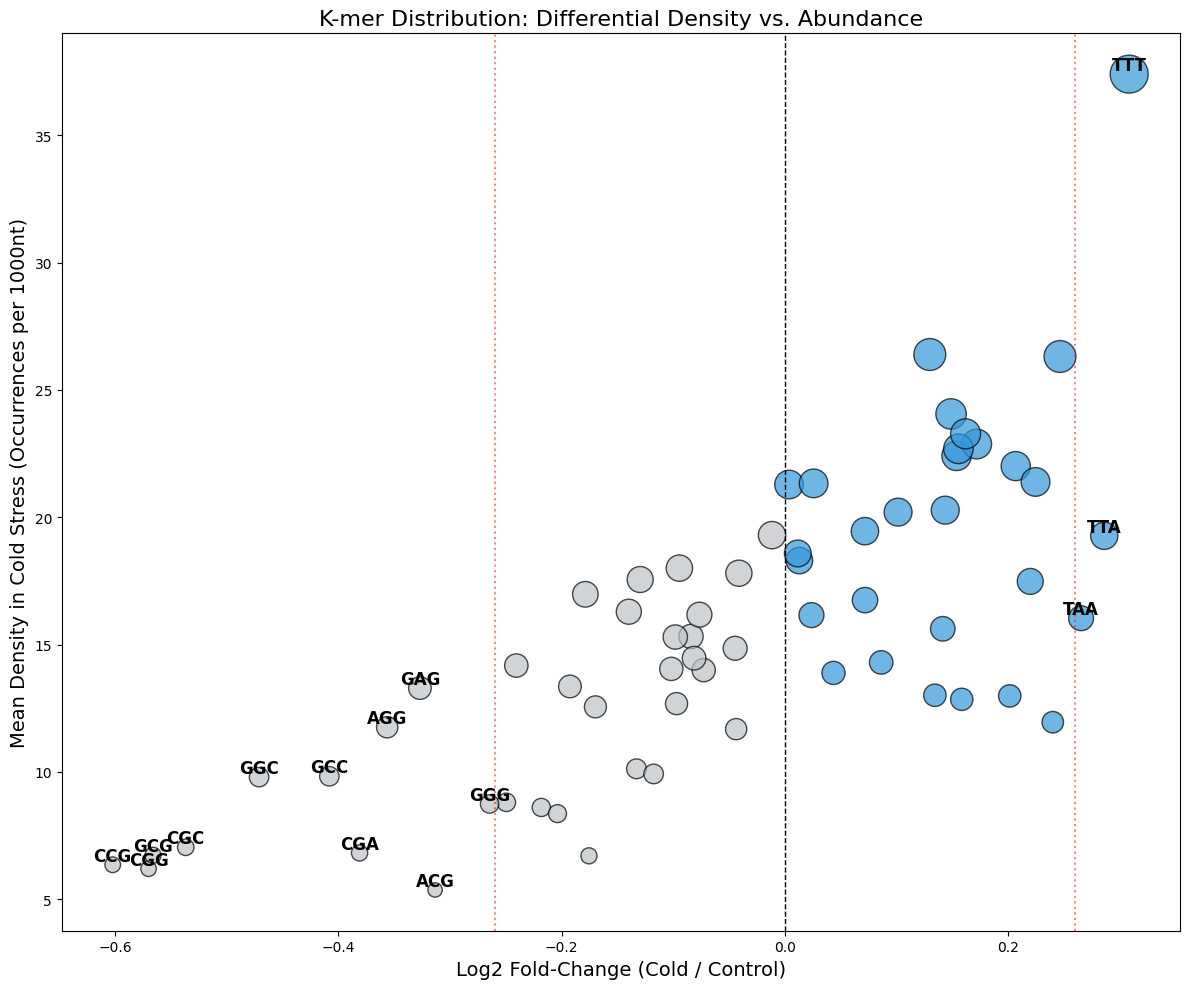

In [27]:
plt.figure(figsize=(12, 10))

colors = ['#3498db' if x > 0 else '#bdc3c7' for x in df_comp['Log2FC']]

scatter = plt.scatter(df_comp['Log2FC'], df_comp['Cold_Avg'],
                      s=df_comp['Cold_Avg']*20, # Tamanho do ponto pela densidade
                      c=colors, edgecolors='black', alpha=0.7)

for i, txt in enumerate(df_comp.index):
    if abs(df_comp['Log2FC'].iloc[i]) > 0.26: # Filtro de simetria (|Log2FC| > 0.26)
        plt.annotate(txt, (df_comp['Log2FC'].iloc[i], df_comp['Cold_Avg'].iloc[i]),
                     fontsize=12, fontweight='bold', ha='center', va='bottom')

plt.axvline(0, color='black', linestyle='--', linewidth=1) # Linha central
plt.axvline(0.26, color='red', linestyle=':', alpha=0.5)   # Threshold aumento
plt.axvline(-0.26, color='red', linestyle=':', alpha=0.5)  # Threshold redução

plt.title('K-mer Distribution: Differential Density vs. Abundance', fontsize=16)
plt.xlabel('Log2 Fold-Change (Cold / Control)', fontsize=14)
plt.ylabel('Mean Density in Cold Stress (Occurrences per 1000nt)', fontsize=14)


plt.tight_layout()

plt.show()

/tmp/ipython-input-2042380090.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Log2FC', y=top_plot.index, data=top_plot, palette=colors)


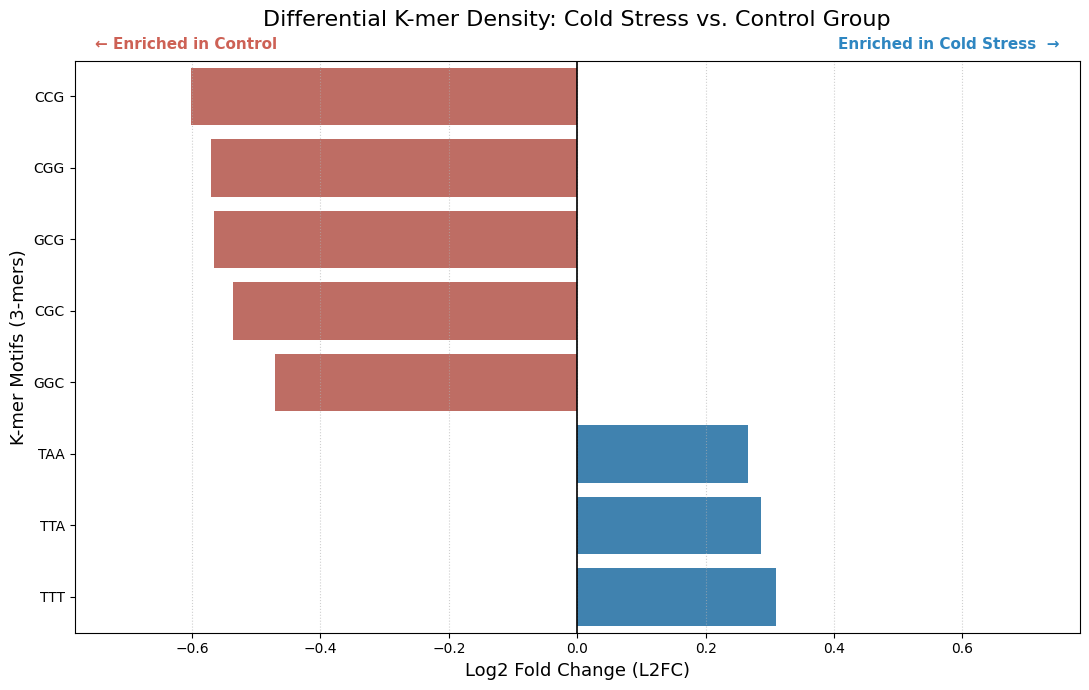

In [30]:
top_plot = pd.concat([enriched_subtle.head(5), depleted_subtle.head(5)])
top_plot = top_plot.sort_values(by='Log2FC')

plt.figure(figsize=(11, 7))

# Color palette: Reddish for Control/Depleted, Blueish for Cold/Enriched
colors = ['#cd6155' if x < 0 else '#2e86c1' for x in top_plot['Log2FC']]

# 2. Create the horizontal bar plot
ax = sns.barplot(x='Log2FC', y=top_plot.index, data=top_plot, palette=colors)

# 3. Dynamic X-axis limits
# Provides 30% extra space to prevent bars from touching the edges
x_limit = max(abs(top_plot['Log2FC'].min()), abs(top_plot['Log2FC'].max())) * 1.3
plt.xlim(-x_limit, x_limit)

# 4. Titles and Labels
plt.title('Differential K-mer Density: Cold Stress vs. Control Group', fontsize=16, pad=25)
plt.xlabel('Log2 Fold Change (L2FC)', fontsize=13)
plt.ylabel('K-mer Motifs (3-mers)', fontsize=13)

# Add a central reference line
plt.axvline(0, color='black', linewidth=1.2, linestyle='-')

# 5. Strategic Label Placement (Top corners)
# Using axes fraction ensures labels remain fixed regardless of data values
plt.text(0.98, 1.02, 'Enriched in Cold Stress  →',
         transform=ax.transAxes, color='#2e86c1', fontweight='bold', ha='right', fontsize=11)

plt.text(0.02, 1.02, '← Enriched in Control ',
         transform=ax.transAxes, color='#cd6155', fontweight='bold', ha='left', fontsize=11)

# Fine-tuning aesthetics
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()

# 6. High-Resolution TIFF Export for Thesis/Publication
# Using 300 DPI and LZW compression for professional quality
plt.savefig('cold_differential_density_plot.tiff',
            dpi=300,
            format='tiff',
            bbox_inches='tight',
            pil_kwargs={'compression': 'tiff_lzw'})

plt.show()

The Delta ($\Delta$) Argument (Absolute Abundance)

The Log2FC Argument (Relative Sensitivity)

In [31]:
# CircRNA: osa-circ2961-OS07T0191200 / MLLALIWKFDFPPFMVLIIAILNDVGF / ATPase
target_sequence = "TTGGTTTTATGCTTCTTGCTCTGATATGGAAGTTCGATTTCCCACCATTTATGGTCCTGATCATTGCCATCCTCAATGACG"

# 1. Calculate density using the standardized function
density_results = calculate_kmer_density(target_sequence)

# 2. Convert to DataFrame and set column names
df_sorted = density_results.to_frame(name='Density_Per_1000nt')
df_sorted.index.name = 'K-mer'

# 3. Sort by density (Descending order)
df_final = df_sorted.sort_values(by='Density_Per_1000nt', ascending=False)

# 4. Print both extremes (Top and Bottom 10)
print("="*50)
print(f"{'TOP 10 HIGHEST DENSITY':^50}")
print("="*50)
print(df_final.head(10))

print("\n" + "="*50)
print(f"{'TOP 10 LOWEST DENSITY':^50}")
print("="*50)
print(df_final.tail(10))

              TOP 10 HIGHEST DENSITY              
       Density_Per_1000nt
K-mer                    
TTT             49.382716
ATG             49.382716
TTG             37.037037
TCC             37.037037
GAT             37.037037
CCA             37.037037
CAT             37.037037
TTC             37.037037
TAT             37.037037
ATT             37.037037

              TOP 10 LOWEST DENSITY               
       Density_Per_1000nt
K-mer                    
GGG                   0.0
GGC                   0.0
CCG                   0.0
GCG                   0.0
GCA                   0.0
CGC                   0.0
GAG                   0.0
CGG                   0.0
AAC                   0.0
AAA                   0.0


In [32]:
# osa-circ5529-OS12T0236100; phospholipase A1 PLIP2 ; MALCQMIFAQIQFNIPCLKHWSQTHQSSRESL
target_sequence = "CTCATCAATCATCAAGAGAATCCTTGATGGCTTTGTGCCAGATGATTTTTGCCCAGATCCAGTTCAACATTCCTTGCTTGAAGCACTGGAGTCAGA"

# 1. Calculate density using the standardized function
density_results = calculate_kmer_density(target_sequence)

# 2. Convert to DataFrame and set column names
df_sorted = density_results.to_frame(name='Density_Per_1000nt')
df_sorted.index.name = 'K-mer'

# 3. Sort by density (Descending order)
df_final = df_sorted.sort_values(by='Density_Per_1000nt', ascending=False)

# 4. Print both extremes (Top and Bottom 10)
print("="*50)
print(f"{'TOP 10 HIGHEST DENSITY':^50}")
print("="*50)
print(df_final.head(10))

print("\n" + "="*50)
print(f"{'TOP 10 LOWEST DENSITY':^50}")
print("="*50)
print(df_final.tail(10))

              TOP 10 HIGHEST DENSITY              
       Density_Per_1000nt
K-mer                    
TCA             62.500000
TTG             52.083333
ATC             52.083333
AGA             52.083333
TTT             41.666667
CAG             41.666667
CTT             41.666667
GAT             41.666667
CCA             31.250000
CAA             31.250000

              TOP 10 LOWEST DENSITY               
       Density_Per_1000nt
K-mer                    
AGG                   0.0
GCG                   0.0
ATA                   0.0
GAC                   0.0
CTA                   0.0
CGT                   0.0
CGG                   0.0
CGC                   0.0
CGA                   0.0
AAA                   0.0


In [33]:
# osa-circ2995-OS01T0679900 ; osa-miR1428a-3p
target_sequence = "GTATCCTTCTCACTCGTTCTACGGAGCGCGCCGAATCCCCCGCCCTCTGCTATTTGAGGGGGGTGGATCTGATGTGTGTGCTTGCTGGTGTTCCGGTGCATGTTTTCGCTGTCGATCAATGGGATTTCTCGATGTTTTTGGAGCTACTTTAGATTTTGAATGGTGGTGAGTTTGGTGGTTCTGATCCCATTGTTCCTTCCTCTAGAGTTTGCTGATACATGGGGAAGTACTAGTACTTTTTTGTTGGATCGAAATTCTCGATTTTGTCTTTTACTCTTGTTCAGTAAAAGTTATGGTTATGATGATCGGCGCGTGCTTCTTTTCTCGCTGTTTTTTTTTTAGAAATATCGGCGTGGCATCTACTAGTTCTAGTTGTGTTCATCCCAGCTTTGTTAGTCGAAAAAAACTTTTGGTTTTACTCAAGTTTCCAATTTCTTTTTGTTGAAAAAAAAACTTTGCCTCATCCAAAGGTTATTATTATTTCTTAATCGCGATCACTATTTAGAAAAATATTATATCGAATTTATCACGGGATTATAGTCGCTTCCATAGGCTTTGATCAAAACTTTGATCCATTTCAATCTCGATATTATTGAGTTTTGCCGGCCTATCATGTGCCTCTATTATTAGGATTTTGAGAGATGGTGAGAGCCGAGCCAACTCCCATTTACGCGGCAGGTGGTACACCAATTATTTGGTTTCTCTGTGTCCATGGACTTGCTTAGTCTCAACGGTTAGGCCTGGACGTCTGGTGTGGTGCTGCAGGCCGCACCTCCTAATCTCCCCTTAATCTCAACTCCTTGGCCAGCCTCGTGTTCGTGCTTAATCAAATGATCCCTGTTTATTTTTCAGATCTGTTAATCTCATGAGTTCTTGAAAGGGCAATTATTAGCTGAGCATGATTGAACTAGGGAATTGTTTATTTGTCATTCTGGCGTGGTTGGCTTACTTTATTGCTCACTCATGGACAACGACCTTTTTCAATTTGTTTTGCGATCCTTGA"
# 1. Calculate density using the standardized function
density_results = calculate_kmer_density(target_sequence)

# 2. Convert to DataFrame and set column names
df_sorted = density_results.to_frame(name='Density_Per_1000nt')
df_sorted.index.name = 'K-mer'

# 3. Sort by density (Descending order)
df_final = df_sorted.sort_values(by='Density_Per_1000nt', ascending=False)

# 4. Print both extremes (Top and Bottom 10)
print("="*50)
print(f"{'TOP 10 HIGHEST DENSITY':^50}")
print("="*50)
print(df_final.head(10))

print("\n" + "="*50)
print(f"{'TOP 10 LOWEST DENSITY':^50}")
print("="*50)
print(df_final.tail(10))

              TOP 10 HIGHEST DENSITY              
       Density_Per_1000nt
K-mer                    
TTT             66.799601
TTG             33.898305
ATT             31.904287
TTA             30.907278
GTT             30.907278
TCT             27.916251
CTT             26.919242
ATC             25.922233
TGT             25.922233
TTC             24.925224

              TOP 10 LOWEST DENSITY               
       Density_Per_1000nt
K-mer                    
TAA              5.982054
CCG              5.982054
CAG              5.982054
ACG              5.982054
CAC              5.982054
GTA              4.985045
AAG              4.985045
GAC              3.988036
ACC              2.991027
ACA              2.991027


In [34]:
# osa-circ5532-OS04T0543900 ; Glutamate dehydrogenase
target_sequence = "TTGATCCAGATGAAGTAAATGCACTTGCTCAACTAATGACATGGAAGACTGCTGTTGCAGCAATTCCATATGGTGGAGCAAAGGGTGGGATTGGATGCGCTCCTGGTGAATTAAGCACGAGTGAGCTGGAGCGTTTGACACGTGTATTTACACAGAAAATTCATGATCTTATTGGAGCTCATACTGACGTGCCAGCTCCTGACATGGGAACTAATTCACAGGTATATTCTGCTTTCTCTAGTATTTTTCTACTACTTCCCTTCATCATGTAACATCCCCTGTAATTTTGACACAGACCATGGCTTGGATTTTGGATGAGTACTCGAAATTCCATGGTCATTCACCGGCAGTTGTCACTGGGAAGCCAATAGTAAGTATACTATACAACAACACAAATCTAGTTTGTGTAAATAACAATTTACATCCAGTGATTGTATTTTGGATATTTTTGTTGTAGGATCTTGGTGGATCATTAGGTAGAGATGCTGCTACAGGAAGAGGTGTGATGTACGCTACTGAGGCTCTTTTGGCTGAACATGGAAAGTCCATTTCTGGATCAACCTTTGTTATCCAG"

# 1. Calculate density using the standardized function
density_results = calculate_kmer_density(target_sequence)

# 2. Convert to DataFrame and set column names
df_sorted = density_results.to_frame(name='Density_Per_1000nt')
df_sorted.index.name = 'K-mer'

# 3. Sort by density (Descending order)
df_final = df_sorted.sort_values(by='Density_Per_1000nt', ascending=False)

# 4. Print both extremes (Top and Bottom 10)
print("="*50)
print(f"{'TOP 10 HIGHEST DENSITY':^50}")
print("="*50)
print(df_final.head(10))

print("\n" + "="*50)
print(f"{'TOP 10 LOWEST DENSITY':^50}")
print("="*50)
print(df_final.tail(10))

              TOP 10 HIGHEST DENSITY              
       Density_Per_1000nt
K-mer                    
TTT             36.585366
TGG             34.843206
ATT             33.101045
TTG             31.358885
ACA             29.616725
GGA             27.874564
ATG             26.132404
CAT             26.132404
TGA             26.132404
GTA             24.390244

              TOP 10 LOWEST DENSITY               
       Density_Per_1000nt
K-mer                    
GTC              5.226481
ACC              5.226481
CGT              5.226481
CGC              3.484321
GCG              3.484321
GCC              3.484321
CGA              3.484321
CGG              1.742160
TCG              1.742160
CCG              1.742160


In [35]:
# osa-circ41148-OS02T0122000 ; histone deacetylase complex
target_sequence = "GTGAAAGAGGTTGCTCTTGCAGCAAGAAAAAGAAATGCAAGGCTTTCTTTTGCTTTCGTGTACCCTGATAAGCATGGTCGTTTCGTTGTCAAAGA"

# 1. Calculate density using the standardized function
density_results = calculate_kmer_density(target_sequence)

# 2. Convert to DataFrame and set column names
df_sorted = density_results.to_frame(name='Density_Per_1000nt')
df_sorted.index.name = 'K-mer'

# 3. Sort by density (Descending order)
df_final = df_sorted.sort_values(by='Density_Per_1000nt', ascending=False)

# 4. Print both extremes (Top and Bottom 10)
print("="*50)
print(f"{'TOP 10 HIGHEST DENSITY':^50}")
print("="*50)
print(df_final.head(10))

print("\n" + "="*50)
print(f"{'TOP 10 LOWEST DENSITY':^50}")
print("="*50)
print(df_final.tail(10))

              TOP 10 HIGHEST DENSITY              
       Density_Per_1000nt
K-mer                    
AAA             63.157895
AAG             63.157895
TTT             52.631579
CTT             42.105263
TGC             42.105263
TTG             42.105263
GCA             42.105263
AGA             42.105263
GCT             31.578947
CGT             31.578947

              TOP 10 LOWEST DENSITY               
       Density_Per_1000nt
K-mer                    
CCG                   0.0
CGA                   0.0
CGC                   0.0
GGG                   0.0
CGG                   0.0
GGA                   0.0
CTA                   0.0
GCG                   0.0
GCC                   0.0
GAC                   0.0
